# Advanced model fitting: calibrating the MONARCH model

## Introduction
The goal of this notebook is to calibrate our lab's MONARCH model to a synthetic data set, as published in Jones & Oomen [1]. We will generate a synthetic data set using MONARCH and calibrate the model to this synthetic data using CHAMLEON to check if we can recapitulate the known model parameters. We will calibrate a single heart beat simulation as well as a growth simulation. The outline will be:
1. Generating the synthetic data
2. Fitting the baseline model
3. Fitting the chronic model

In [9]:
# Enable automatically reloading modules when they have changed
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


When rerunning this notebook, set the run_sims variable to false to skip the simulation step and only run the GPEs and implausibility calculations. Simulations ran previously will be loaded and this will tremendously speed up the process.

In [10]:
import pathlib

main_dir = pathlib.Path.cwd() / "demo_monarch"
run_sims = True

In [11]:
from monarch import Hatch

# Initialize model
input_vo = "P21_Hx"
beats = Hatch(input_vo)

We want to set a few constants to ensure a realistic wall geometry of all ventricles at all times. This is important because we only want to fit the LV parameters in this case, and want to have realistic geometries for the other chambers for every chosen parameter set. These constants include a ratio of midwall reference areas takes from [2], and the wall thicknesses of all other chambers than the LV at end-diastole from [3].

In [12]:
#model_constants = {"AmRefRfwRatio": 1.3, "AmRefSwRatio": 0.53, "AmRefLARatio": 0.70, "AmRefRARatio": 0.51,
#                   "RfwVRatio": 0.584, "SwVRatio": 0.607, "LAWVRatio": 0.0924, "RAWVRatio": 0.0410}

#beats.change_pars(model_constants)

In [13]:
beats.clear_converged_sol()
beats.just_beat_it(print_solve=True)

Iteration 0:	1.90e-01 8.13e+00 7.92e-01 5.57e-01 1.98e-01 5.85e+00 7.29e-02 2.48e-01
Iteration 1:	3.53e-01 1.18e-01 9.18e-01 9.38e-02 2.15e-02 2.79e-03 1.90e-02 1.91e-01
Iteration 2:	2.00e-01 3.44e-02 6.92e-01 2.61e-02 2.33e-02 3.02e-03 3.53e-02 1.35e-01
Iteration 3:	1.18e-01 1.66e-02 9.05e+00 1.21e-02 2.29e-02 2.96e-03 6.98e-02 9.09e-02
Iteration 4:	7.50e-02 9.94e-03 1.21e+00 1.30e-02 2.20e-02 2.85e-03 8.70e-02 6.50e-02
Iteration 5:	4.86e-02 6.32e-03 4.97e-01 2.01e-02 2.05e-02 2.68e-03 8.89e-02 5.53e-02
Iteration 6:	3.00e-02 3.89e-03 2.52e-01 2.80e-02 1.86e-02 2.45e-03 8.02e-02 5.42e-02
Iteration 7:	1.60e-02 2.10e-03 1.43e-01 3.29e-02 1.63e-02 2.16e-03 6.86e-02 5.40e-02
Iteration 8:	5.33e-03 7.44e-04 8.92e-02 3.46e-02 1.37e-02 1.83e-03 5.88e-02 5.15e-02
Iteration 9:	2.72e-03 2.82e-04 5.94e-02 3.41e-02 1.11e-02 1.49e-03 5.09e-02 4.76e-02
Iteration 10:	8.72e-03 1.05e-03 4.10e-02 3.23e-02 8.61e-03 1.17e-03 4.44e-02 4.30e-02
Iteration 11:	1.31e-02 1.62e-03 2.86e-02 2.99e-02 6.28e-03 8.56e

In [14]:
beats.outputs.LVEDP
beats.outputs.RVEDP

0    3.175859
Name: RVEDP, dtype: float64

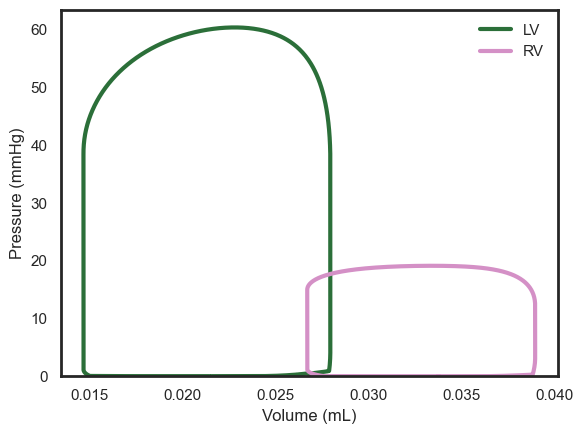

In [15]:
# Import plotting functions
import monarch.metamorphoses as meta

# Plot LV pressure-volume loop
meta.pv_loop(beats, compartments=("LV", "RV"))

In [16]:
beats.outputs.LabLfw

AttributeError: 'DataFrame' object has no attribute 'LabLfw'

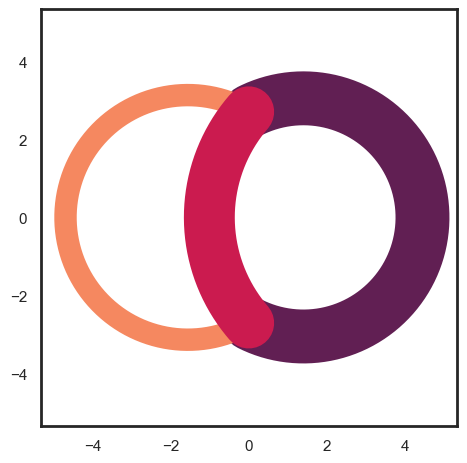

In [ ]:
meta.cardiac_geometry(beats, real_wall_thickness=True)

#### Baseline
CHAMELEON's Camouflage class is expecting a Pandas dataframe with all information for each output variable, which we set up here. We need `mu` (mean) and `sigma` (standard deviation), and optional the lower and upper limits labeled as `min` and `max`, resp. The time point of needs to be specified by `_label`, for a non-growth simulation this can be `_baseline` and/or `_acute`. We provide a utility function to convert the data to this format, and save it as a .csv file for documentation.

In [ ]:
from chameleon.utils import convert_data
import pandas as pd

roi_baseline = ["RVEDV", "RVESV", "RVEDP", "RVESP","dpdt_max_rv","dpdt_min_rv"]


data_baseline = pd.read_csv("demo_monarch/data/data_baseline_P21_Hx.csv",index_col=0)
data_baseline

,mu_baseline,sigma_baseline,min,max
RVEDV,0.050890,0.01207,0.025,0.08
RVESV,0.023510,0.00967,0.005,0.04
RVEDP,2.990000,1.98000,0.100,20.00
RVESP,35.580000,5.11000,20.000,60.00
RVMaxdP,1826.090088,561.55000,1000.000,3000.00
RVMindP,-1422.342668,408.71000,-2200.000,-800.00
